In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

In [2]:
train_dir = "../data/chest_xray/train"
val_dir = "../data/chest_xray/val"
test_dir = "../data/chest_xray/test"

## Проверка структуры датасета

In [3]:
print(os.listdir(train_dir))

['NORMAL', 'PNEUMONIA']


## Подсчет количества изображений

In [4]:
def count_images(data_dir):
    counts = {}

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)

        counts[class_name] = len(os.listdir(class_path))

    return counts

In [5]:
train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

print("Train:", train_counts)
print("Val:", val_counts)
print("Test:", test_counts)

Train: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Val: {'NORMAL': 8, 'PNEUMONIA': 8}
Test: {'NORMAL': 234, 'PNEUMONIA': 390}


## Визуализация распределения классов

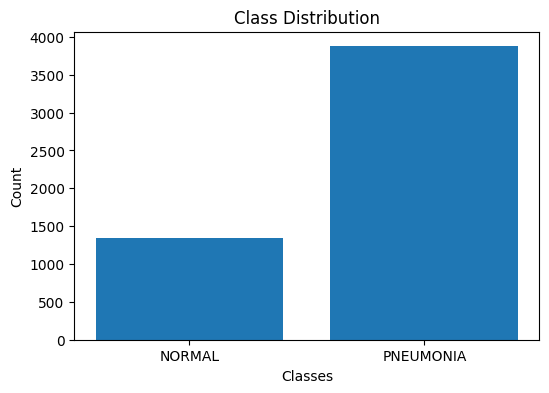

In [6]:
plt.figure(figsize=(6,4))

plt.bar(
    train_counts.keys(),
    train_counts.values()
)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")

plt.show()

Вывод: в датасете наблюдается дисбаланс классов. Класс PNEUMONIA представлен значительно чаще, что может привести к смещению модели.

## Просмотр изображений

In [7]:
def show_images(data_dir, class_name, n=5):

    class_path = os.path.join(data_dir, class_name)

    images = os.listdir(class_path)[:n]

    plt.figure(figsize=(15,5))

    for i, image_name in enumerate(images):

        image_path = os.path.join(class_path, image_name)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, n, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(class_name)
        plt.axis("off")

    plt.show()

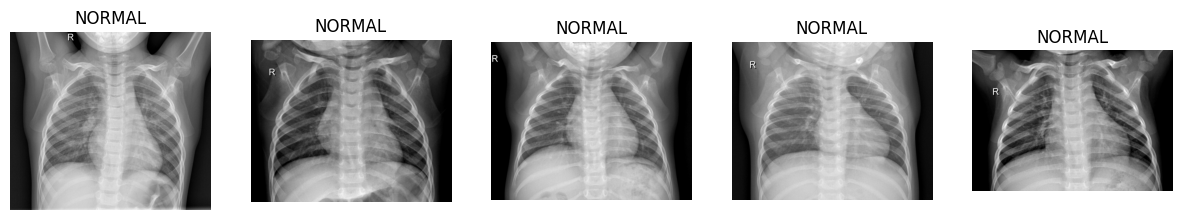

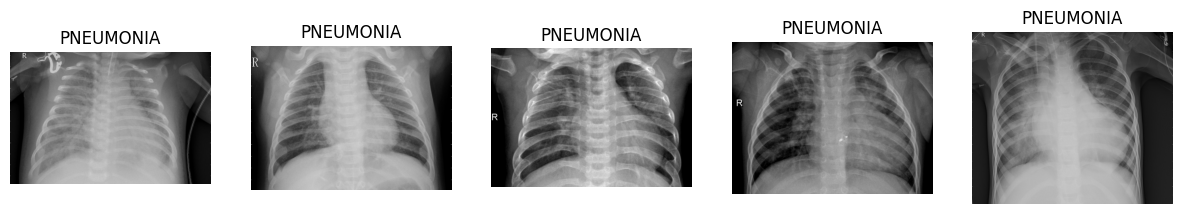

In [8]:
show_images(train_dir, "NORMAL")
show_images(train_dir, "PNEUMONIA")

У PNEUMONIA часто:
- затемнения
- неоднородности
- белые области
- менее “чистые” легкие

## Проверка размеров изображений

In [9]:
def get_image_sizes(data_dir):

    sizes = []

    for class_name in os.listdir(data_dir):

        class_path = os.path.join(data_dir, class_name)

        for image_name in os.listdir(class_path):

            image_path = os.path.join(class_path, image_name)

            image = Image.open(image_path)

            sizes.append(image.size)

    return sizes

In [10]:
sizes = get_image_sizes(train_dir)

Counter(sizes).most_common(10)

[((1072, 648), 7),
 ((1080, 728), 6),
 ((1008, 680), 5),
 ((976, 672), 5),
 ((1216, 872), 5),
 ((992, 592), 5),
 ((1064, 760), 5),
 ((1008, 704), 5),
 ((1304, 968), 4),
 ((1088, 712), 4)]

Вывод: изображения имеют различное разрешение, поэтому перед обучением выполняется resize до фиксированного размера 224x224.

## Проверка grayscale

In [13]:
sample_path = os.path.join(
    train_dir,
    "NORMAL",
    os.listdir(os.path.join(train_dir, "NORMAL"))[0]
)

image = cv2.imread(sample_path)

print(image.shape)

(1858, 2090, 3)


In [12]:
sample_path = os.path.join(
    train_dir,
    "NORMAL",
    os.listdir(os.path.join(train_dir, "NORMAL"))[0]
)

image = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

print(image.shape)

(1858, 2090)


Вывод:
- 1858 - высота (pixels)
- 2090 - ширина (pixels)
- 3 - количество каналов

Изображения представлены в формате RGB (3 канала), однако по своей природе являются grayscale. Перед обучением выполняется преобразование в одноканальный формат.

## Анализ яркости

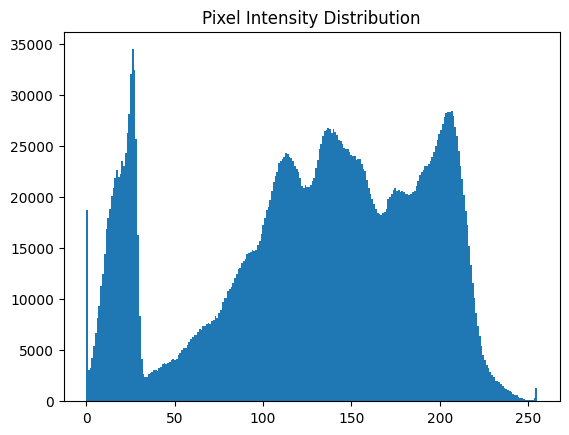

In [14]:
image = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

plt.hist(image.ravel(), bins=256)
plt.title("Pixel Intensity Distribution")
plt.show()

Вывод:

Изображение содержит разные типы областей:
- темные (фон, воздух)
- средние (ткани)
- светлые (кости, уплотнения)

Гистограмма показывает мультимодальное распределение яркости, что соответствует различным анатомическим структурам. Изображение имеет широкий динамический диапазон, что является хорошим признаком для обучения CNN.

## Проверка поврежденных изображений

In [15]:
broken_images = []

for class_name in os.listdir(train_dir):

    class_path = os.path.join(train_dir, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        image = cv2.imread(image_path)

        if image is None:
            broken_images.append(image_path)

print("Broken images:", len(broken_images))

Broken images: 0


## Проверка среднего размера

In [16]:
widths = []
heights = []

for size in sizes:
    widths.append(size[0])
    heights.append(size[1])

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Average width: 1320.6108128834355
Average height: 968.0747699386503


## Предобработка

In [5]:
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [ ]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)):
        self.clahe = cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid_size
        )

    def __call__(self, image):
        return self.clahe.apply(image)

train_transforms = A.Compose([
    A.Resize(224, 224),

    A.HorizontalFlip(p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    A.Rotate(limit=10, p=0.5),

    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),

    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(224, 224),

    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),

    ToTensorV2()
])

class XRayDataset(Dataset):
    def __init__(self, root_dir, transform=None, use_clahe=True):
        self.root_dir = root_dir
        self.transform = transform
        self.use_clahe = use_clahe
        self.clahe = CLAHETransform()

        self.images = []
        self.labels = []

        for label, class_name in enumerate(["NORMAL", "PNEUMONIA"]):
            class_path = os.path.join(root_dir, class_name)

            for img_name in os.listdir(class_path):
                self.images.append(os.path.join(class_path, img_name))
                self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]

        # grayscale
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # CLAHE
        if self.use_clahe:
            image = self.clahe(image)

        # Albumentations expects HWC
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]

        label = self.labels[idx]

        return image, label

train_dataset = XRayDataset(
    "../data/chest_xray/train",
    transform=train_transforms
)

val_dataset = XRayDataset(
    "../data/chest_xray/val",
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [7]:
import matplotlib.pyplot as plt

def show_before_after(dataset, index=0):
    img_path = dataset.images[index]

    # original
    original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # after transform
    transformed, _ = dataset[index]
    transformed = transformed.squeeze().numpy()

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(transformed, cmap='gray')
    plt.title("After preprocessing")
    plt.axis("off")

    plt.show()

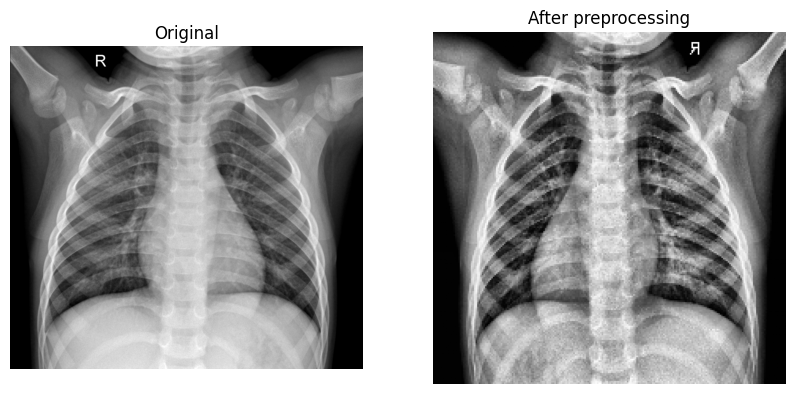

In [8]:
show_before_after(train_dataset, index=10)

Для повышения качества изображений применялась
адаптивная гистограммная эквализация (CLAHE),
что позволило усилить локальный контраст.

Все изображения были приведены к размеру 224x224
и нормализованы.

Для обучающей выборки применялись аугментации:
горизонтальное отражение, изменение яркости и
небольшие повороты.

ETL pipeline реализован следующим образом:

Extract:
Загрузка изображений с диска с использованием OpenCV.

Transform:
Применение CLAHE, изменение размера изображений,
аугментации и нормализация.

Load:
Формирование батчей с помощью PyTorch DataLoader
для подачи в модель.